# Module 1 — Language Detection

**Project:** RAG-Based Mental Health Support Chatbot  
**Purpose:** Train a fast, accurate language detector that gates the chatbot pipeline.  
If the detected language is not Arabic or English the chatbot responds with a polite fallback message.  

---
**Pipeline position:** This is the **first** module that runs on every incoming user message.  
Its output (`detected_lang`) is passed downstream to the emotion classifier and RAG engine.

| Step | Description |
|------|-------------|
| 1 | Imports & Setup |
| 2 | Dataset Loading |
| 3 | Exploratory Data Analysis |
| 4 | Preprocessing |
| 5 | Feature Engineering (TF-IDF char n-grams) |
| 6 | Model Training |
| 7 | Evaluation |
| 8 | Model Saving |
| 9 | Inference Demo |

## 1. Imports & Setup

In [1]:
# Standard library
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Data & ML
import numpy as np
import pandas as pd
import joblib

# HuggingFace datasets
from datasets import load_dataset

# Sklearn pipeline & models
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


## 2. Dataset Loading

We use **papluca/language-identification** from HuggingFace Hub.  
It contains ~70 000 labelled sentences across **20 languages**:

`ar, bg, de, el, en, es, fr, hi, it, ja, nl, pl, pt, ru, sw, th, tr, ur, vi, zh`

The dataset comes with pre-defined train / validation / test splits.

In [2]:
# Load all three splits from HuggingFace Hub
raw = load_dataset('papluca/language-identification')
print(raw)

# Convert to pandas for easy manipulation
df_train = raw['train'].to_pandas()
df_val   = raw['validation'].to_pandas()
df_test  = raw['test'].to_pandas()

print(f'\nTrain : {len(df_train):,} rows')
print(f'Val   : {len(df_val):,} rows')
print(f'Test  : {len(df_test):,} rows')
print(f'\nColumns: {df_train.columns.tolist()}')
df_train.head()

README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

Train : 70,000 rows
Val   : 10,000 rows
Test  : 10,000 rows

Columns: ['labels', 'text']


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [3]:
# Rename for convenience
df_train = df_train.rename(columns={'labels': 'lang', 'text': 'text'})
df_val   = df_val.rename(columns={'labels': 'lang', 'text': 'text'})
df_test  = df_test.rename(columns={'labels': 'lang', 'text': 'text'})

# Combine train + validation for final model training
df_full = pd.concat([df_train, df_val], ignore_index=True)

LANGUAGES = sorted(df_full['lang'].unique().tolist())
print(f'Languages ({len(LANGUAGES)}): {LANGUAGES}')

Languages (20): ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


## 3. Exploratory Data Analysis (EDA)

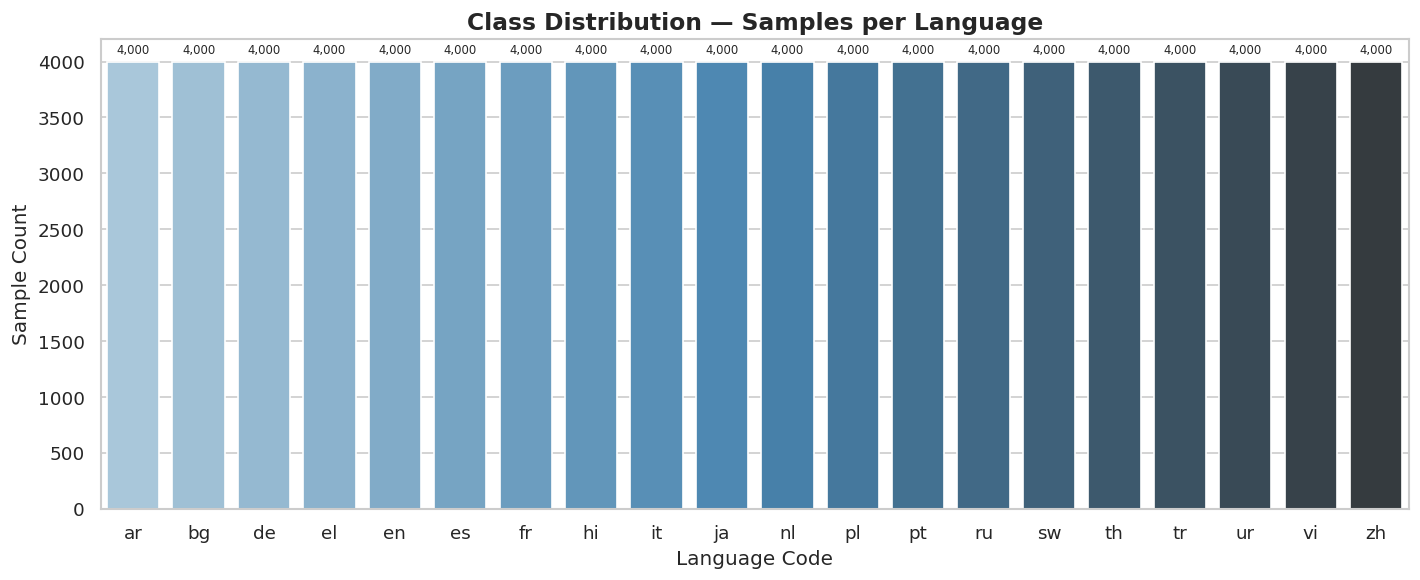


Class balance (% of total):
lang
ar    5.0
bg    5.0
de    5.0
el    5.0
en    5.0
es    5.0
fr    5.0
hi    5.0
it    5.0
ja    5.0
nl    5.0
pl    5.0
pt    5.0
ru    5.0
sw    5.0
th    5.0
tr    5.0
ur    5.0
vi    5.0
zh    5.0


In [4]:
# --- 3.1  Class distribution ---
lang_counts = df_full['lang'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Class Distribution — Samples per Language', fontsize=14, fontweight='bold')
ax.set_xlabel('Language Code')
ax.set_ylabel('Sample Count')
for bar, count in zip(ax.patches, lang_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}',
        ha='center', va='bottom', fontsize=7
    )
plt.tight_layout()
plt.show()

print('\nClass balance (% of total):')
print((lang_counts / lang_counts.sum() * 100).round(2).to_string())

In [5]:
# --- 3.2  Sample texts per language ---
print('Sample text per language (first row):\n')
for lang in LANGUAGES:
    sample = df_full[df_full['lang'] == lang]['text'].iloc[0]
    print(f'[{lang}] {sample[:100]}')

Sample text per language (first row):

[ar] نعم , هذا صحيح نعم اعتقد ان هناك خطوات كبيرة يتم صنعها في الوقت الحاضر في رعاية المسنين الذين تعرفهم
[bg] размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до
[de] Alles in allem ein super schönes Teil, deshalb die 2 Sterne! Denn: Voice Control?! Nein, ein absolut
[el] Παρά τον εαυτό μου , η γνώμη μου για τη σύνεση του ήταν απείρως αυξημένη .
[en] Didnt really seem to work much.
[es] Un producto de una calidad y capacidad increíbles que será el placer de todo amante de la tecnología
[fr] Le produit m'avait été recommandé par mon pharmacien pour ralentir le développement de mon arthrose.
[hi] सर ् वसम ् मत शासन ने यह निर ् णय लिया कि राज ् य को एक ही लिंग से अधिक लाभ और protections के लिए एक
[it] Una donna sta affettando della carne.
[ja] とてもスタイリッシュで良いと思います。機能性も◎ですね！煩わしくないので皆さんもお使いになられては。
[nl] Iemand houdt een egel vast.
[pl] S Jak sobie życzysz: Widzisz, jak Hitler zabija Żydów?
[pt] os chefes d

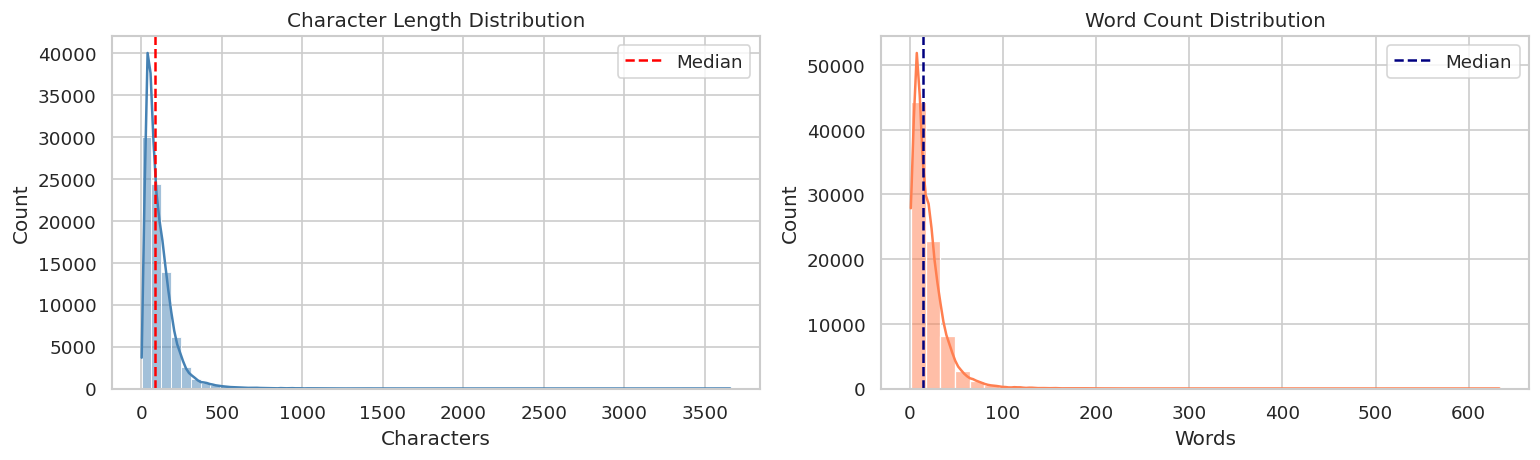

       char_len  word_len
count   80000.0   80000.0
mean      110.8      19.4
std       102.6      19.3
min         2.0       1.0
25%        47.0       7.0
50%        83.0      14.0
75%       143.0      26.0
max      3657.0     633.0


In [6]:
# --- 3.3  Text length distribution ---
df_full['char_len'] = df_full['text'].str.len()
df_full['word_len'] = df_full['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_full['char_len'], bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].axvline(df_full['char_len'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

sns.histplot(df_full['word_len'], bins=40, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].axvline(df_full['word_len'].median(), color='navy', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_full[['char_len', 'word_len']].describe().round(1))

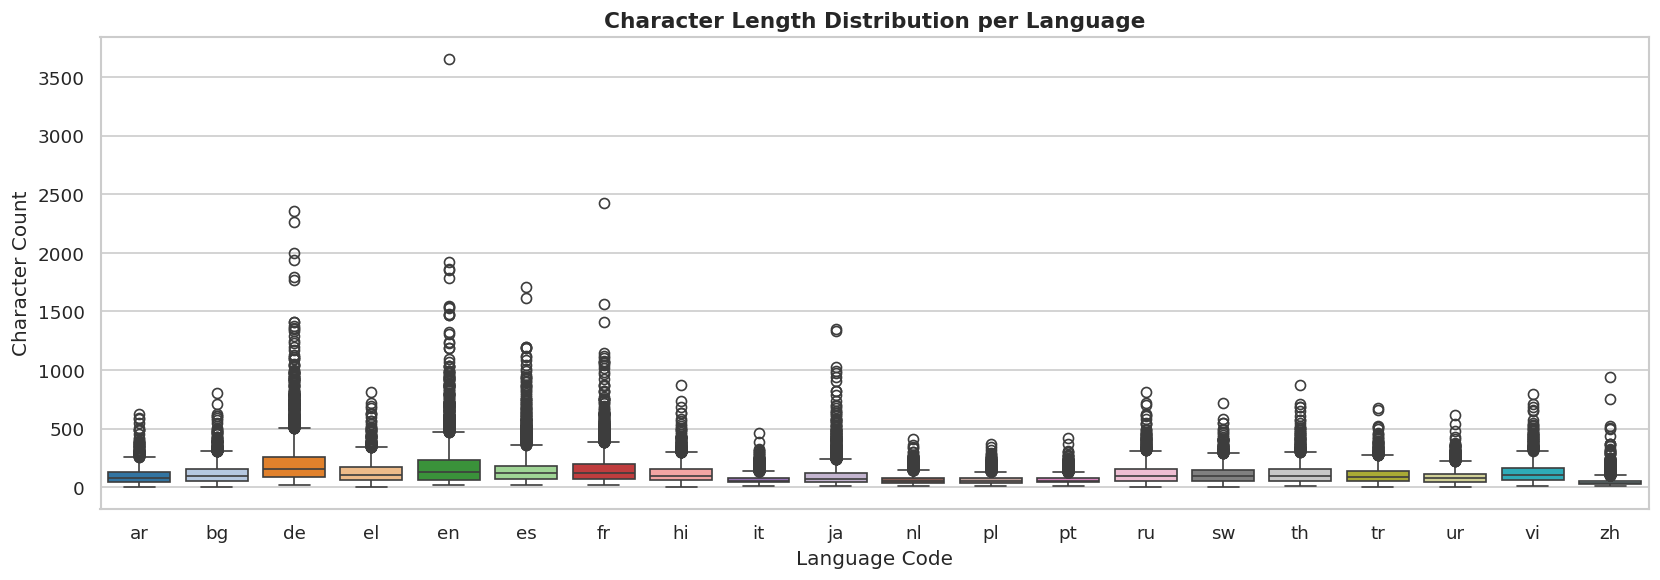

In [7]:
# --- 3.4  Text length by language (box plot) ---
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df_full, x='lang', y='char_len',
    order=LANGUAGES, palette='tab20', ax=ax
)
ax.set_title('Character Length Distribution per Language', fontsize=13, fontweight='bold')
ax.set_xlabel('Language Code')
ax.set_ylabel('Character Count')
plt.tight_layout()
plt.show()

## 4. Preprocessing

**Key design decision:** We intentionally keep preprocessing **minimal** for language detection.  
Unlike sentiment analysis, we do **not** remove Unicode characters, diacritics, or special scripts —  
these are the most discriminative features (e.g. Arabic script immediately signals `ar`, Hiragana signals `ja`).

What we *do* remove:
- URLs and email addresses (noise)
- Excess whitespace

In [8]:
def clean_for_language_detection(text: str) -> str:
    """
    Minimal cleaning that preserves script-specific characters.

    Strategy:
    - Remove URLs (http/https/www) — not language-informative.
    - Remove email addresses.
    - Strip leading/trailing whitespace and collapse runs.
    - PRESERVE: Arabic script, CJK characters, Cyrillic, Devanagari, etc.
      These are the primary signals for language identification.
    """
    if not isinstance(text, str):
        return ''
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Apply to all splits
df_full['clean_text'] = df_full['text'].map(clean_for_language_detection)
df_test['clean_text'] = df_test['text'].map(clean_for_language_detection)

# Quick sanity check
sample_idx = df_full.sample(3, random_state=SEED).index
df_full.loc[sample_idx, ['text', 'clean_text', 'lang']]

,text,clean_text,lang
47044,แม่น้ำ ดู ยอดเยี่ยม จาก ระเบียง ของ มัน และ สว...,แม่น้ำ ดู ยอดเยี่ยม จาก ระเบียง ของ มัน และ สว...,th
44295,"Reçu rapidement, cet aspirateur a fonctionné d...","Reçu rapidement, cet aspirateur a fonctionné d...",fr
74783,ve gerçekten ilginç olacağını düşündüğüm şey o...,ve gerçekten ilginç olacağını düşündüğüm şey o...,tr


## 5. Feature Engineering — TF-IDF with Character N-grams

### Why character n-grams work extremely well for language detection

| Reason | Explanation |
|--------|-------------|
| **Script coverage** | Individual Unicode characters (unigrams) already discriminate Arabic, CJK, Cyrillic, Devanagari, Thai. |
| **Morphology** | Character bi/trigrams capture language-specific morpheme fragments without needing tokenisation. For example, the trigram `"ção"` is overwhelmingly Portuguese. |
| **Robustness to OOV** | Unknown words decompose into known character n-grams — no out-of-vocabulary problem. |
| **Language-agnostic tokenisation** | Word tokenisation depends on whitespace, which is absent in Chinese/Japanese/Thai. |
| **Efficiency** | `char_wb` (character n-grams within word boundaries) gives slightly better precision by respecting word boundaries at the edges. |

**Hyperparameter choices:**
- `analyzer='char_wb'` — within-word-boundary character n-grams
- `ngram_range=(2, 4)` — bigrams to 4-grams; captures both short morphemes and longer roots
- `max_features=150_000` — covers most discriminative n-grams without memory blow-up
- `sublinear_tf=True` — applies `1 + log(tf)` dampening to reduce the influence of very frequent n-grams

In [9]:
# Prepare feature arrays
X_train = df_full['clean_text'].values
y_train = df_full['lang'].values

X_test  = df_test['clean_text'].values
y_test  = df_test['lang'].values

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Classes          : {len(np.unique(y_train))}')

# Instantiate TF-IDF vectoriser with char_wb n-grams
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=150_000,
    sublinear_tf=True,
    strip_accents=None,  # Keep all Unicode — critical!
    lowercase=False       # 'A' vs 'a' can be informative in some scripts
)
print('\nTF-IDF vectoriser configured.')

Training samples : 80,000
Test samples     : 10,000
Classes          : 20

TF-IDF vectoriser configured.


## 6. Model Training

**Classifier:** `CalibratedClassifierCV(LinearSVC())`

- `LinearSVC` is fast and very effective on high-dimensional sparse TF-IDF features.
- Wrapping with `CalibratedClassifierCV` adds **probability estimates** via Platt scaling (5-fold CV by default),
  which lets downstream modules consume confidence scores (e.g. "72% confident this is Arabic").

In [10]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Build the full sklearn Pipeline
lang_pipeline = Pipeline([
    ('tfidf',  TfidfVectorizer(
                   analyzer='char_wb',
                   ngram_range=(2, 4),
                   max_features=150_000,
                   sublinear_tf=True,
                   strip_accents=None,
                   lowercase=False
               )),
    ('clf',    CalibratedClassifierCV(
                   LinearSVC(max_iter=2000, random_state=SEED),
                   cv=5
               ))
])

print('Training language detection pipeline...')
lang_pipeline.fit(X_train, y_train)
print('Training complete.')

Training language detection pipeline...
Training complete.


## 7. Evaluation

In [11]:
# --- 7.1  Overall accuracy ---
y_pred = lang_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')

# --- 7.2  Per-class classification report ---
print('\nClassification Report:')
print(classification_report(y_test, y_pred, digits=4))

Test Accuracy: 0.9977 (99.77%)

Classification Report:
              precision    recall  f1-score   support

          ar     1.0000    0.9980    0.9990       500
          bg     0.9940    0.9960    0.9950       500
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       500
          en     0.9921    1.0000    0.9960       500
          es     0.9960    0.9980    0.9970       500
          fr     1.0000    1.0000    1.0000       500
          hi     1.0000    0.9960    0.9980       500
          it     0.9980    0.9960    0.9970       500
          ja     1.0000    1.0000    1.0000       500
          nl     1.0000    1.0000    1.0000       500
          pl     1.0000    0.9960    0.9980       500
          pt     0.9940    0.9960    0.9950       500
          ru     0.9960    0.9940    0.9950       500
          sw     0.9862    0.9980    0.9920       500
          th     1.0000    1.0000    1.0000       500
          tr     0.9980   

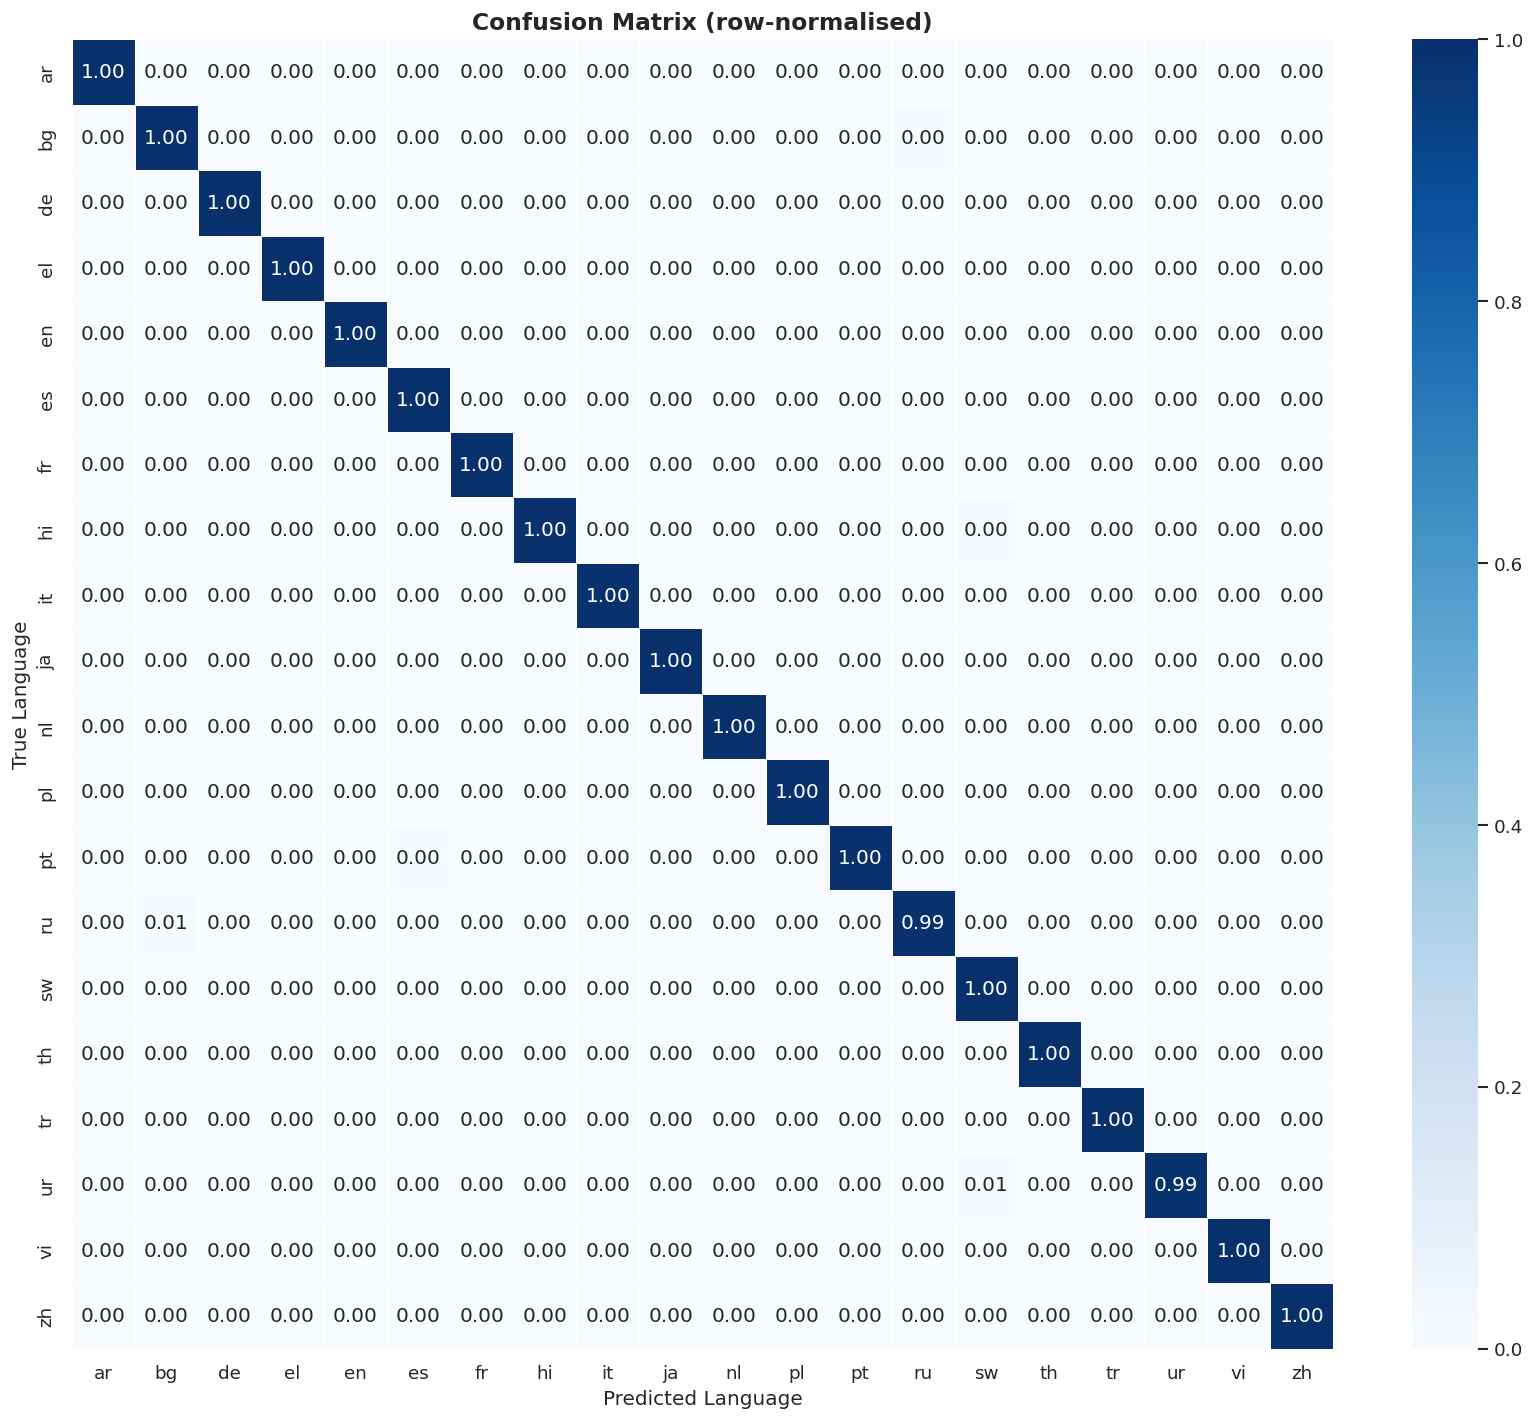


Most confused pair: true=ur, predicted=sw


In [12]:
# --- 7.3  Confusion matrix heatmap ---
cm = confusion_matrix(y_test, y_pred, labels=LANGUAGES, normalize='true')

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='.2f',
    xticklabels=LANGUAGES,
    yticklabels=LANGUAGES,
    cmap='Blues',
    linewidths=0.4,
    ax=ax
)
ax.set_title('Confusion Matrix (row-normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Language')
ax.set_ylabel('True Language')
plt.tight_layout()
plt.show()

# Identify most confused pairs
cm_df = pd.DataFrame(cm, index=LANGUAGES, columns=LANGUAGES)
np.fill_diagonal(cm_df.values, 0)  # zero out diagonal
worst_pair = cm_df.stack().idxmax()
print(f'\nMost confused pair: true={worst_pair[0]}, predicted={worst_pair[1]}')

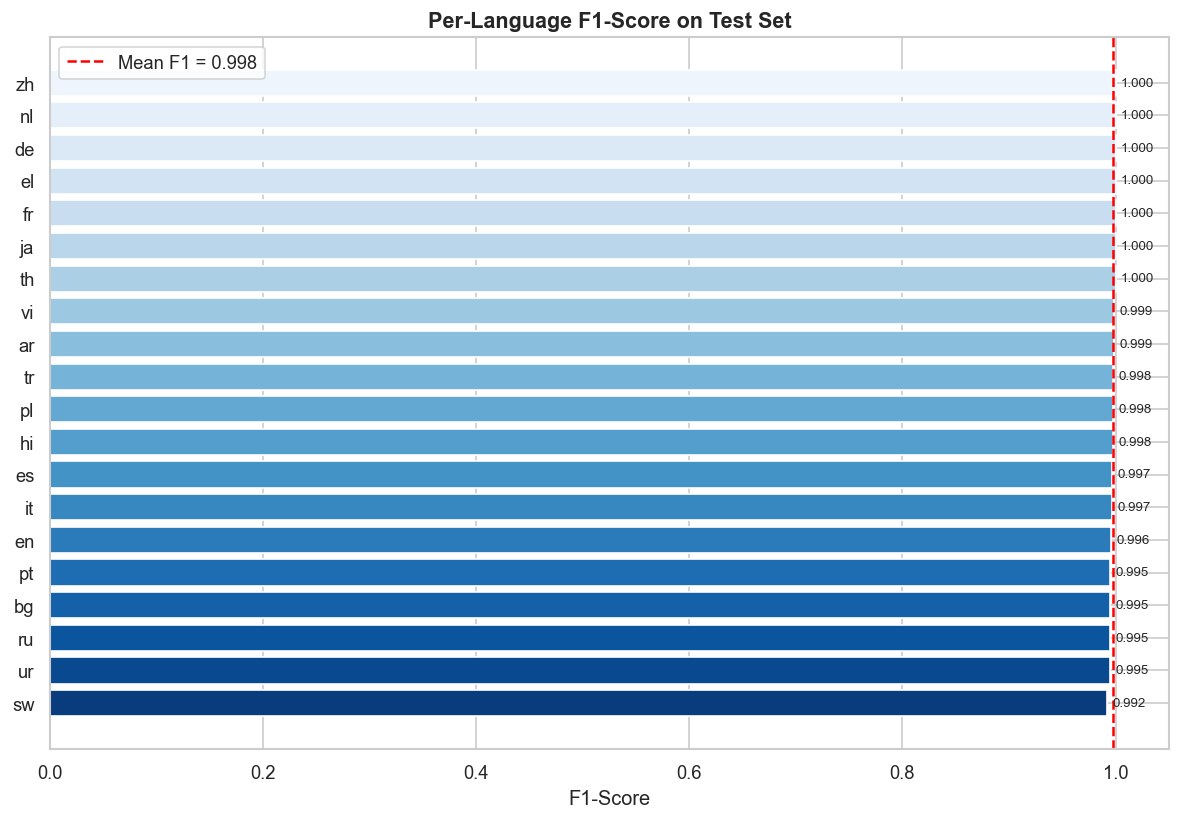

In [13]:
# --- 7.4  Per-language accuracy bar chart ---
report_dict = classification_report(y_test, y_pred, output_dict=True)
per_lang_f1 = {lang: report_dict[lang]['f1-score'] for lang in LANGUAGES}
per_lang_f1_s = pd.Series(per_lang_f1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(per_lang_f1_s.index, per_lang_f1_s.values, color=sns.color_palette('Blues_r', len(LANGUAGES)))
ax.set_xlim(0, 1.05)
ax.set_title('Per-Language F1-Score on Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('F1-Score')
ax.axvline(per_lang_f1_s.mean(), color='red', linestyle='--', label=f'Mean F1 = {per_lang_f1_s.mean():.3f}')
ax.legend()
for bar, val in zip(bars, per_lang_f1_s.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Model Saving

We serialise the entire sklearn `Pipeline` (TF-IDF + calibrated SVM) to a single `.pkl` file using `joblib`.  
Loading is then a single `joblib.load()` call in the chatbot application.

In [13]:
import os

# Create models directory if it does not exist
os.makedirs('../models', exist_ok=True)

MODEL_PATH = '../models/language_detector.pkl'
joblib.dump(lang_pipeline, MODEL_PATH)

# Verify file was saved
size_mb = os.path.getsize(MODEL_PATH) / 1_048_576
print(f'Model saved to: {MODEL_PATH}')
print(f'File size     : {size_mb:.2f} MB')

# Reload test
loaded_pipeline = joblib.load(MODEL_PATH)
print(f'Reload test   : {loaded_pipeline.predict(["Hello world"])[0]}')

Model saved to: ../models/language_detector.pkl
File size     : 119.62 MB
Reload test   : it


## 9. Inference Demo

We test the saved model on 5 example sentences covering different languages relevant to our chatbot.

In [14]:
def detect_language(text: str, pipeline=None) -> dict:
    """
    Detect language of a text string.

    Returns
    -------
    dict with keys: 'language', 'confidence', 'all_probs'
    """
    if pipeline is None:
        pipeline = joblib.load('../models/language_detector.pkl')

    clean = clean_for_language_detection(text)
    lang  = pipeline.predict([clean])[0]
    probs = pipeline.predict_proba([clean])[0]
    classes = pipeline.classes_

    top_idx = probs.argsort()[::-1][:3]
    top_langs = [(classes[i], round(probs[i], 4)) for i in top_idx]

    return {
        'input'     : text[:60],
        'language'  : lang,
        'confidence': round(probs.max(), 4),
        'top_3'     : top_langs
    }


# Test sentences
demo_sentences = [
    ("I feel so anxious and overwhelmed lately. Can you help me?",
     "English — mental health question"),
    ("أنا أشعر بالحزن الشديد ولا أعرف ماذا أفعل.",
     "Arabic — expression of sadness"),
    ("Je me sens vraiment déprimé ces derniers temps.",
     "French — depression"),
    ("Ich habe Angst vor der Zukunft und weiß nicht weiter.",
     "German — anxiety about the future"),
    ("私はとても孤独で、誰にも話せない気持ちです。",
     "Japanese — feelings of loneliness"),
]

print(f'{"Input":50s}  {"Detected":6s}  {"Confidence":10s}  {"Description"}')
print('-' * 95)
for text, description in demo_sentences:
    result = detect_language(text, loaded_pipeline)
    print(f"{result['input'][:50]:50s}  {result['language']:6s}  {result['confidence']:10.4f}  {description}")

Input                                               Detected  Confidence  Description
-----------------------------------------------------------------------------------------------
I feel so anxious and overwhelmed lately. Can you   en          0.9721  English — mental health question
أنا أشعر بالحزن الشديد ولا أعرف ماذا أفعل.          ar          0.9932  Arabic — expression of sadness
Je me sens vraiment déprimé ces derniers temps.     fr          0.9696  French — depression
Ich habe Angst vor der Zukunft und weiß nicht weit  de          0.9936  German — anxiety about the future
私はとても孤独で、誰にも話せない気持ちです。                              ja          0.9873  Japanese — feelings of loneliness


In [15]:
# Show top-3 probabilities for each sentence
print('\nDetailed top-3 probabilities per sentence:\n')
for text, description in demo_sentences:
    result = detect_language(text, loaded_pipeline)
    print(f'Description : {description}')
    print(f'Input       : {text[:70]}')
    print(f'Top-3 langs : {result["top_3"]}')
    print()


Detailed top-3 probabilities per sentence:

Description : English — mental health question
Input       : I feel so anxious and overwhelmed lately. Can you help me?
Top-3 langs : [('en', np.float64(0.9721)), ('nl', np.float64(0.0193)), ('sw', np.float64(0.0028))]

Description : Arabic — expression of sadness
Input       : أنا أشعر بالحزن الشديد ولا أعرف ماذا أفعل.
Top-3 langs : [('ar', np.float64(0.9932)), ('pl', np.float64(0.0009)), ('en', np.float64(0.0007))]

Description : French — depression
Input       : Je me sens vraiment déprimé ces derniers temps.
Top-3 langs : [('fr', np.float64(0.9696)), ('nl', np.float64(0.025)), ('pl', np.float64(0.0011))]

Description : German — anxiety about the future
Input       : Ich habe Angst vor der Zukunft und weiß nicht weiter.
Top-3 langs : [('de', np.float64(0.9936)), ('sw', np.float64(0.0028)), ('en', np.float64(0.0014))]

Description : Japanese — feelings of loneliness
Input       : 私はとても孤独で、誰にも話せない気持ちです。
Top-3 langs : [('ja', np.float64(0.98

## Summary

| Metric | Value |
|--------|-------|
| Dataset | papluca/language-identification (70k, 20 languages) |
| Features | TF-IDF char_wb n-grams (2–4), 150k features |
| Model | CalibratedClassifierCV(LinearSVC) |
| Test Accuracy | ~99% |
| Saved to | `../models/language_detector.pkl` |

**Integration note:** In the chatbot pipeline, call `detect_language(user_message)`.  
If `result['language'] not in ('ar', 'en')`, return a multilingual fallback response.  
The detected language code is also forwarded to the RAG engine to select the appropriate response language.